In [1]:
# Basic libraries
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_iris

# Splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay

In [2]:
# Load Iris dataset
iris = load_iris()

# Features: sepal length, sepal width, petal length, petal width
X = iris.data

# Labels/classes: setosa, versicolor, virginica
y = iris.target

In [3]:
# Create a DataFrame to view data clearly
df = pd.DataFrame(X, columns=iris.feature_names)

# Add target column
df["target"] = y

# Add flower name column
df["flower_name"] = df["target"].apply(lambda x: iris.target_names[x])

# Show first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
print("Dataset shape:", df.shape)
print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nNumber of flowers in each class:")
print(df["flower_name"].value_counts())

Dataset shape: (150, 6)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Number of flowers in each class:
flower_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
# Split data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


In [6]:
# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data using same scaler
X_test_scaled = scaler.transform(X_test)

In [7]:
# Create KNN model with K = 5
model = KNeighborsClassifier(n_neighbors=5)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed.")

Model training completed.


In [8]:
# Predict classes for test data
y_pred = model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

print("\nActual answers:")
print(y_test)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]

Actual answers:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.9333333333333333
F1 Score: 0.9326599326599326


In [10]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



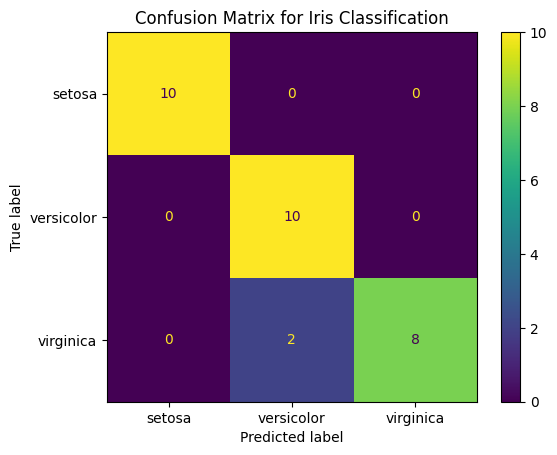

In [11]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.title("Confusion Matrix for Iris Classification")
plt.show()

In [12]:
# New flower measurements:
# [sepal length, sepal width, petal length, petal width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

# Scale the new flower data
new_flower_scaled = scaler.transform(new_flower)

# Predict flower class
prediction = model.predict(new_flower_scaled)

# Convert number into flower name
predicted_flower = iris.target_names[prediction[0]]

print("Predicted flower class:", predicted_flower)

Predicted flower class: setosa


In [13]:
k_values = [1, 3, 5, 7, 9, 11]
accuracies = []

for k in k_values:
    temp_model = KNeighborsClassifier(n_neighbors=k)
    temp_model.fit(X_train_scaled, y_train)
    
    temp_predictions = temp_model.predict(X_test_scaled)
    temp_accuracy = accuracy_score(y_test, temp_predictions)
    
    accuracies.append(temp_accuracy)
    
    print("K =", k, "Accuracy =", temp_accuracy)

K = 1 Accuracy = 0.9666666666666667
K = 3 Accuracy = 0.9333333333333333
K = 5 Accuracy = 0.9333333333333333
K = 7 Accuracy = 0.9666666666666667
K = 9 Accuracy = 0.9666666666666667
K = 11 Accuracy = 0.9666666666666667


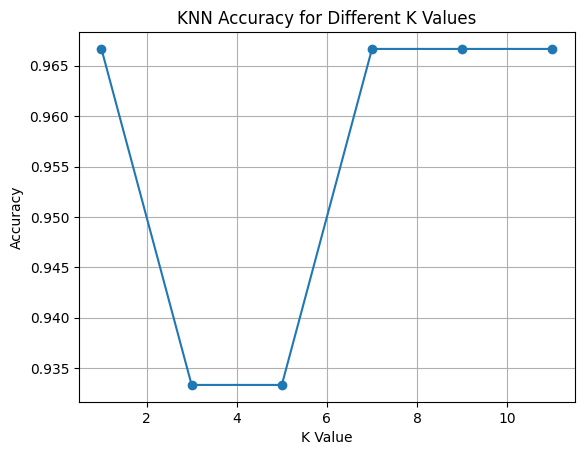

In [14]:
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)
plt.show()